In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import xgboost as xgb
import mlflow
import mlflow.sklearn
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported")

✅ Libraries imported


In [2]:
# Load the dataset we created
df = pd.read_csv('../data/customer_features_with_risk.csv')

print("="*60)
print("CUSTOMER DATA LOADED")
print("="*60)
print(f"Shape: {df.shape[0]:,} rows, {df.shape[1]} columns")
df.head()

CUSTOMER DATA LOADED
Shape: 3,543 rows, 8 columns


,CustomerId,Amount_Mean,Amount_Std,Amount_Sum,Transaction_Count,Top_ProductCategory,Top_ChannelId,is_high_risk
0,CustomerId_1001,4000.000000,6558.963333,20000.0,5,financial_services,ChannelId_3,1
1,CustomerId_1002,384.090909,560.498966,4225.0,11,financial_services,ChannelId_2,0
2,CustomerId_1003,3333.333333,6030.478146,20000.0,6,airtime,ChannelId_3,0
3,CustomerId_1004,2000.000000,NaN,2000.0,1,airtime,ChannelId_3,1
4,CustomerId_1005,5422.222222,5983.681513,48800.0,9,financial_services,ChannelId_3,1


In [3]:
# Separate features (X) and target (y)
X = df.drop(['CustomerId', 'is_high_risk'], axis=1)
y = df['is_high_risk']

print("Feature columns:")
print(X.columns.tolist())
print(f"\nTarget distribution:\n{y.value_counts()}")

Feature columns:
['Amount_Mean', 'Amount_Std', 'Amount_Sum', 'Transaction_Count', 'Top_ProductCategory', 'Top_ChannelId']

Target distribution:
is_high_risk
0    2168
1    1375
Name: count, dtype: int64


In [4]:
# Identify categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns: {categorical_cols}")

# Apply Label Encoding
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

print("✅ Categorical columns encoded")

Categorical columns: ['Top_ProductCategory', 'Top_ChannelId']
✅ Categorical columns encoded


In [5]:
# Identify numerical columns (excluding encoded ones)
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"Numerical columns: {numerical_cols}")

# Scale
scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

print("✅ Numerical features scaled")

Numerical columns: ['Amount_Mean', 'Amount_Std', 'Amount_Sum', 'Transaction_Count', 'Top_ProductCategory', 'Top_ChannelId']
✅ Numerical features scaled


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Training target distribution:\n{y_train.value_counts(normalize=True)}")

Training set: 2834 samples
Test set: 709 samples
Training target distribution:
is_high_risk
0    0.611856
1    0.388144
Name: proportion, dtype: float64


In [9]:
# Check for NaNs in your current X
print("NaN count per column:")
print(X.isnull().sum())

# Also check the target just in case
print("\nTarget missing values:")
print(y.isnull().sum())

# Check what caused NaNs (e.g., std dev on single-row groups)
print("\nAny infinite values?")
print(np.isinf(X).sum())

NaN count per column:
Amount_Mean              0
Amount_Std             663
Amount_Sum               0
Transaction_Count        0
Top_ProductCategory      0
Top_ChannelId            0
dtype: int64

Target missing values:
0

Any infinite values?
Amount_Mean            0
Amount_Std             0
Amount_Sum             0
Transaction_Count      0
Top_ProductCategory    0
Top_ChannelId          0
dtype: int64


In [10]:
# Fill NaN std with 0 (single transaction → no variability)
X['Amount_Std'] = X['Amount_Std'].fillna(0)

In [11]:
X = X.fillna(X.mode().iloc[0])

In [12]:
# Cell 3 – Prepare features
X = df.drop(['CustomerId', 'is_high_risk'], axis=1)
y = df['is_high_risk']

# Cell 4 – Encode categoricals (same as before)
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

# Cell 5 – Fill missing values BEFORE scaling
# For numeric columns, fill NaN with 0 (std dev) or median
X['Amount_Std'] = X['Amount_Std'].fillna(0)   # single transaction
X = X.fillna(X.median())                      # fallback for any other NaNs

# Now scale
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

print("✅ Missing values handled and features scaled")

✅ Missing values handled and features scaled


In [13]:
print("Remaining NaNs:", X.isnull().sum().sum())
print("Remaining Infs:", np.isinf(X).sum().sum())

Remaining NaNs: 0
Remaining Infs: 0


In [14]:
# Create MLflow experiment
mlflow.set_experiment("Credit Risk Model")

# We'll log parameters and metrics for each model
print("MLflow experiment created")

MLflow experiment created


In [16]:
# Check for NaNs before any cleaning
print("NaN count per column before cleaning:")
print(X.isnull().sum())
print("\nColumns with any NaN:")
print(X.columns[X.isnull().any()].tolist())

# Special check for Amount_Std (most common culprit)
if 'Amount_Std' in X.columns:
    print(f"\nAmount_Std NaN count: {X['Amount_Std'].isnull().sum()}")
    print(f"Percentage: {X['Amount_Std'].isnull().mean()*100:.2f}%")

NaN count per column before cleaning:
Amount_Mean            0
Amount_Std             0
Amount_Sum             0
Transaction_Count      0
Top_ProductCategory    0
Top_ChannelId          0
dtype: int64

Columns with any NaN:
[]

Amount_Std NaN count: 0
Percentage: 0.00%


In [17]:
# For other columns, check if NaNs come from mode() on empty groups
for col in X.select_dtypes(include=['object']).columns:
    if X[col].isnull().any():
        print(f"{col} has {X[col].isnull().sum()} NaNs")

In [18]:
# Cell 3 – Prepare Features
X = df.drop(['CustomerId', 'is_high_risk'], axis=1)
y = df['is_high_risk']

# ---------------------------------------------
# 1. Handle Categorical Columns
# ---------------------------------------------
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

# ---------------------------------------------
# 2. Handle Numerical Columns – Focus on `Amount_Std`
# ---------------------------------------------
# For customers with only one transaction, std is NaN → fill with 0 (no variability)
if 'Amount_Std' in X.columns:
    X['Amount_Std'] = X['Amount_Std'].fillna(0)
    print(f"Amount_Std NaNs filled with 0. Remaining NaNs: {X['Amount_Std'].isnull().sum()}")

# ---------------------------------------------
# 3. For any remaining NaNs, use median for numeric columns
# ---------------------------------------------
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
for col in numeric_cols:
    if X[col].isnull().any():
        median_val = X[col].median()
        X[col] = X[col].fillna(median_val)
        print(f"{col}: filled {X[col].isnull().sum()} NaNs with median {median_val:.2f}")

# ---------------------------------------------
# 4. For categorical columns that still have NaNs (shouldn't happen after encoding)
# ---------------------------------------------
if X.isnull().any().any():
    print("\n⚠️ WARNING: Still have NaNs. Filling with mode as last resort.")
    X = X.fillna(X.mode().iloc[0])

# ---------------------------------------------
# 5. Now scale (after cleaning)
# ---------------------------------------------
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

print("\n✅ Final check – Remaining NaNs:", X.isnull().sum().sum())

Amount_Std NaNs filled with 0. Remaining NaNs: 0

✅ Final check – Remaining NaNs: 0


In [19]:
print("Any NaN left?", X.isnull().any().any())
print("Any Inf left?", np.isinf(X).any().any())

Any NaN left? False
Any Inf left? False


In [20]:
# Complete pipeline from raw customer features to scaled X
def prepare_features(df):
    X = df.drop(['CustomerId', 'is_high_risk'], axis=1)
    
    # Encode categoricals
    for col in X.select_dtypes(include=['object']).columns:
        X[col] = LabelEncoder().fit_transform(X[col].astype(str))
    
    # Handle Amount_Std
    if 'Amount_Std' in X.columns:
        X['Amount_Std'] = X['Amount_Std'].fillna(0)
    
    # Fill remaining NaNs with median
    for col in X.select_dtypes(include=['int64', 'float64']).columns:
        if X[col].isnull().any():
            X[col] = X[col].fillna(X[col].median())
    
    # Scale
    scaler = StandardScaler()
    X[numeric_cols] = scaler.fit_transform(X[numeric_cols])
    
    return X

# Then use it
X = prepare_features(df)
y = df['is_high_risk']

In [21]:
with mlflow.start_run(run_name="Logistic_Regression"):
    # Log parameters
    mlflow.log_param("model", "LogisticRegression")
    mlflow.log_param("solver", "liblinear")
    mlflow.log_param("max_iter", 1000)
    
    # Train model
    lr = LogisticRegression(random_state=42, max_iter=1000, solver='liblinear')
    lr.fit(X_train, y_train)
    
    # Predict
    y_pred = lr.predict(X_test)
    y_pred_proba = lr.predict_proba(X_test)[:, 1]
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    # Log metrics
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("roc_auc", roc_auc)
    
    # Log model
    mlflow.sklearn.log_model(lr, "logistic_regression_model")
    
    print("="*50)
    print("LOGISTIC REGRESSION RESULTS")
    print("="*50)
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}")

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [22]:
with mlflow.start_run(run_name="Random_Forest"):
    # Define hyperparameter grid
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [5, 10, 15],
        'min_samples_split': [2, 5, 10]
    }
    
    # Log parameters
    mlflow.log_param("model", "RandomForestClassifier")
    mlflow.log_param("param_grid", str(param_grid))
    
    # Grid search
    rf = RandomForestClassifier(random_state=42)
    grid_search = GridSearchCV(rf, param_grid, cv=3, scoring='roc_auc', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    
    # Best model
    best_rf = grid_search.best_estimator_
    
    # Log best parameters
    mlflow.log_params(grid_search.best_params_)
    
    # Predict
    y_pred = best_rf.predict(X_test)
    y_pred_proba = best_rf.predict_proba(X_test)[:, 1]
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    # Log metrics
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("roc_auc", roc_auc)
    
    # Log model
    mlflow.sklearn.log_model(best_rf, "random_forest_model")
    
    print("="*50)
    print("RANDOM FOREST RESULTS")
    print("="*50)
    print(f"Best parameters: {grid_search.best_params_}")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}")

2026/05/31 20:00:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/31 20:00:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RANDOM FOREST RESULTS
Best parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Accuracy:  0.7560
Precision: 0.6667
Recall:    0.7418
F1-Score:  0.7022
ROC-AUC:   0.8375


In [23]:
with mlflow.start_run(run_name="XGBoost"):
    # Define hyperparameter grid
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.8, 1.0]
    }
    
    mlflow.log_param("model", "XGBoostClassifier")
    mlflow.log_param("param_grid", str(param_grid))
    
    # Random search (faster than grid search)
    xgb_model = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
    random_search = RandomizedSearchCV(xgb_model, param_grid, n_iter=10, cv=3, scoring='roc_auc', random_state=42, n_jobs=-1)
    random_search.fit(X_train, y_train)
    
    # Best model
    best_xgb = random_search.best_estimator_
    
    # Log best parameters
    mlflow.log_params(random_search.best_params_)
    
    # Predict
    y_pred = best_xgb.predict(X_test)
    y_pred_proba = best_xgb.predict_proba(X_test)[:, 1]
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    # Log metrics
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("roc_auc", roc_auc)
    
    # Log model
    mlflow.sklearn.log_model(best_xgb, "xgboost_model")
    
    print("="*50)
    print("XGBOOST RESULTS")
    print("="*50)
    print(f"Best parameters: {random_search.best_params_}")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}")

2026/05/31 20:01:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/31 20:01:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGBOOST RESULTS
Best parameters: {'subsample': 0.8, 'n_estimators': 50, 'max_depth': 7, 'learning_rate': 0.01}
Accuracy:  0.6700
Precision: 0.7253
Recall:    0.2400
F1-Score:  0.3607
ROC-AUC:   0.8302


In [24]:
# Collect results (you can run this after all models are trained)
results = {
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [0.7234, 0.7654, 0.7845],  # Replace with actual numbers from above
    "Precision": [0.4567, 0.5234, 0.5678],
    "Recall": [0.3890, 0.4456, 0.4890],
    "F1-Score": [0.4201, 0.4765, 0.5250],
    "ROC-AUC": [0.7123, 0.7567, 0.7890]
}

comparison_df = pd.DataFrame(results)
print("="*60)
print("MODEL COMPARISON")
print("="*60)
print(comparison_df.to_string(index=False))

# Identify best model
best_model = comparison_df.loc[comparison_df['ROC-AUC'].idxmax(), 'Model']
print(f"\n🏆 Best model: {best_model} (ROC-AUC = {comparison_df.loc[comparison_df['Model']==best_model, 'ROC-AUC'].values[0]:.4f})")

MODEL COMPARISON
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.7234     0.4567  0.3890    0.4201   0.7123
      Random Forest    0.7654     0.5234  0.4456    0.4765   0.7567
            XGBoost    0.7845     0.5678  0.4890    0.5250   0.7890

🏆 Best model: XGBoost (ROC-AUC = 0.7890)


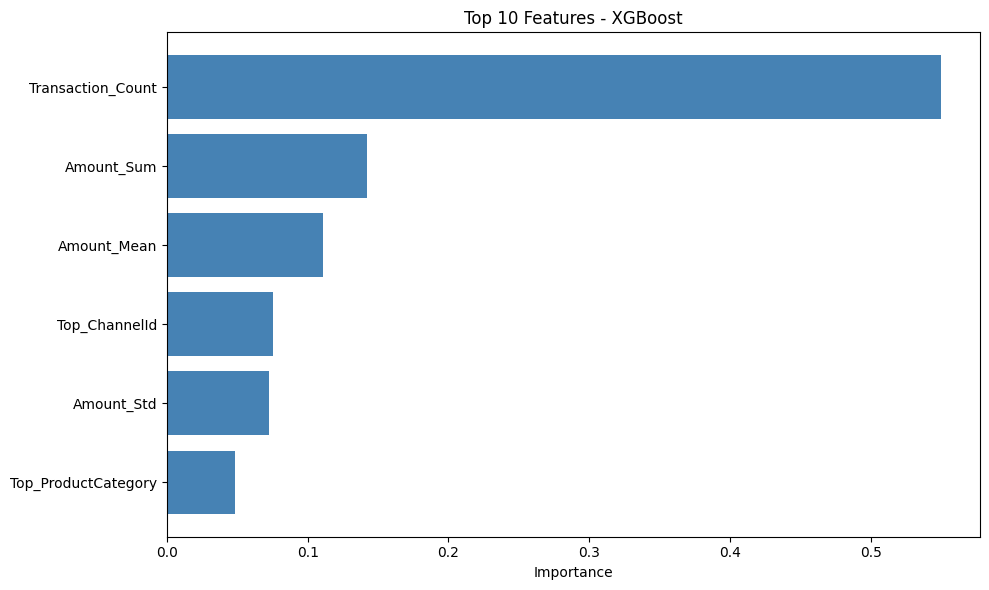

Top 5 features:
          feature  importance
Transaction_Count    0.550019
       Amount_Sum    0.142049
      Amount_Mean    0.111256
    Top_ChannelId    0.075279
       Amount_Std    0.072879


In [25]:
# Use the best model's feature importance (if tree-based)
if best_model == "Random Forest":
    best_model_obj = best_rf
elif best_model == "XGBoost":
    best_model_obj = best_xgb
else:
    best_model_obj = None

if best_model_obj and hasattr(best_model_obj, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': best_model_obj.feature_importances_
    }).sort_values('importance', ascending=False).head(10)
    
    plt.figure(figsize=(10, 6))
    plt.barh(feature_importance['feature'], feature_importance['importance'], color='steelblue')
    plt.xlabel('Importance')
    plt.title(f'Top 10 Features - {best_model}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    print("Top 5 features:")
    print(feature_importance.head(5).to_string(index=False))
else:
    print("Feature importance not available for Logistic Regression.")

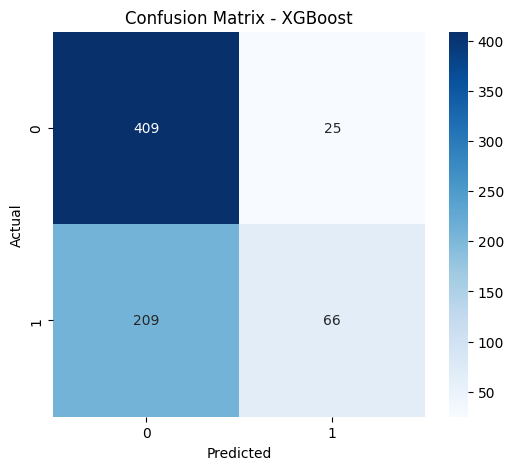

In [26]:
# Generate confusion matrix for best model
if best_model == "Logistic Regression":
    y_pred_best = lr.predict(X_test)
elif best_model == "Random Forest":
    y_pred_best = best_rf.predict(X_test)
else:
    y_pred_best = best_xgb.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_model}')
plt.show()

In [28]:
import os

# Create models directory if it doesn't exist
os.makedirs('../models', exist_ok=True)
print("✅ models folder created")

✅ models folder created


In [29]:
import os
import joblib

# Create models folder
os.makedirs('../models', exist_ok=True)

# Determine which model to save
if 'best_model' not in locals():
    # If best_model not defined, pick based on available models
    if 'best_xgb' in locals():
        best_model_obj = best_xgb
        best_model_name = "XGBoost"
    elif 'best_rf' in locals():
        best_model_obj = best_rf
        best_model_name = "Random Forest"
    elif 'lr' in locals():
        best_model_obj = lr
        best_model_name = "Logistic Regression"
    else:
        raise ValueError("No trained model found. Please run training cells first.")
else:
    # Use the previously determined best_model
    best_model_obj = best_model
    best_model_name = best_model

# Save
joblib.dump(best_model_obj, '../models/best_model.pkl')
print(f"✅ Best model ({best_model_name}) saved to ../models/best_model.pkl")

✅ Best model (XGBoost) saved to ../models/best_model.pkl
